## React Agent Introduction

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

load_dotenv()

llm_googleai = ChatGoogleGenerativeAI(model="gemini-flash-latest", temperature=0)

## Tools

In [ ]:
# Tool-1 : DuckDuckGo Search Tool

from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

search_tool.invoke("A random fact about NBA player Carmelo Anthony")

"He spent two seasons with the Portland Trail Blazers before finishing off his career with the Los Angeles Lakers. Anthony has played in the Olympics for the US national team a record four times, winning a bronze medal with the 2004 squad and gold medals on the 2008, 2012, and 2016 teams. Dec 22, 2016 · In Anthony ’s freshman season, he led the Orangemen to their first and only National Championship and was named the NCAA Tournament’s Most Outstanding Player. Anthony then entered the 2003 NBA draft where he was selected with the third overall pick by the Denver Nuggets. Find out more facts about him, here! Oct 8, 2023 · Discover 15 astonishing facts about NBA superstar Carmelo Anthony and his remarkable career in this insightful article. Oct 31, 2025 · When Carmelo chose the number 00 for his jersey during the NBA bubble, it wasn’t random. To him, the number symbolized infinite peace—a personal mantra and a hope for the future. Carmelo Anthony ' s scoring prowess is considered to have 

In [4]:
# Tool-2 : Wikipedia Tool

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
wiki_tool.invoke("Tell me fun fact about Hunter X Hunter anime")

'Page: List of Hunter × Hunter characters\nSummary: The Hunter × Hunter manga series, created by Yoshihiro Togashi, features an extensive cast of characters. It takes place in a fictional universe where licensed specialists known as Hunters travel the world taking on special jobs ranging from treasure hunting to assassination. The story initially focuses on Gon Freecss and his quest to become a Hunter in order to find his father, Ging, who is himself a famous Hunter. On the way, Gon meets and becomes close friends with Killua Zoldyck, Kurapika and Leorio Paradinight.\nAlthough most characters are human, most possess superhuman strength or supernatural abilities due to Nen, the ability to control one\'s own life energy or aura. The world of the series also includes fantastical beasts such as the Chimera Ants and the Five great calamities.\n\nPage: KPop Demon Hunters\nSummary: KPop Demon Hunters is a 2025 American animated musical urban fantasy film directed by Maggie Kang and Chris Appe

In [9]:
Toolkit = [search_tool, wiki_tool]

## ReAct Agent

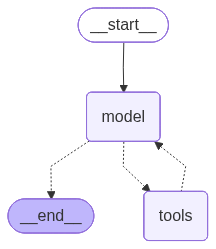

In [12]:
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

Toolkit = [search_tool, wiki_tool]
model = ChatGoogleGenerativeAI(model="gemini-flash-latest", temperature=0)
agent = create_agent(model, tools=Toolkit)
agent

## Invoking React Agent Using Streams

In [19]:
example_querry = "Give me the top facts about the NBA Player Stephen Curry."

events = agent.stream(
    {"messages": [("user", example_querry)]},
    stream_mode = "values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Give me the top facts about the NBA Player Stephen Curry.
================================== Ai Message ==================================
Tool Calls:
  wikipedia (41c5442c-4e89-4253-b6c2-9d769addd23b)
 Call ID: 41c5442c-4e89-4253-b6c2-9d769addd23b
  Args:
    query: Stephen Curry
================================= Tool Message =================================
Name: wikipedia

Page: Stephen Curry
Summary: Wardell Stephen Curry II ( STEF-ən; born March 14, 1988), also known as Steph Curry ( STEF), is an American professional basketball player for the Golden State Warriors of the National Basketball Association (NBA), where he plays as a point guard. Nicknamed "Chef Curry", he is widely regarded as the greatest shooter in basketball history and is credited with revolutionizing the game by popularizing the three-point shot across all levels of basketball.
He is a four-time NBA champion, a two-time NBA Most V

## LLM Binding with Tools

In [18]:
llm_binded = llm_googleai.bind_tools(Toolkit)
llm_binded.invoke("Give me the top facts about the NBA Player Stephen Curry.")

AIMessage(content='', additional_kwargs={'function_call': {'name': 'wikipedia', 'arguments': '{"query": "Stephen Curry"}'}, '__gemini_function_call_thought_signatures__': {'4132b398-aba4-4a8c-9333-90cd418f8737': 'Cv4CAXLI2nxgy98Ep+EXToLzBF7F776F3uJLis6Z+MCyO5PGGW1ytgQZXUYKCEJwCaW8Ha5zBYb2cYM2ZPkvuTJctM/XLnniGylxI90i9ffkl2EtFYbUqVa2I7KiAD2JhIz0Gfjmz3Q4NK2hy9WCsLJ0BukKywMvEzsfMIHxtls2eKLAcsPWCJ0SstYn250cT01Rr5jzVj6bQvcJq4i84ycAX87qOrpDmhR3eUEvU0IX5JTkMaAWdc6cbZJb0Ge6vJHbalIUxGGxaS3hx4Bfcn44oxJ1Mw9lyuZMqyzF2rUhPGnft3fi09wjIOwXQnEryi4H8AQnk3qUBy3tqJcUM/nPvc1YRH9MBm4qjH1JJf3xe4lgYMk1A3q/Co1iPAZCSXajJNbVyuakbI7FVhBclLECjgVJ9F2qR2LrYsD2iS3zMckfW1mTS8hOZX5bPapJGct47bMsdTjQv1vP4Ef0OoFRv++rphQC4BUt3eP/swYr76OaUZqbh9CF3QdzdDOPZQ=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-preview-09-2025', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019bb626-3331-75f0-80c3-5626e4062aed-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'Stephen C